Extraction de données

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import shap

shap.initjs()

# Chargement
url = "https://aws-wh-bucket.s3.eu-north-1.amazonaws.com/final_clean.csv"
df = pd.read_csv(url)

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1943 entries, 0 to 1942
Data columns (total 27 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   year                                       1943 non-null   int64  
 1   country_name                               1943 non-null   str    
 2   life_evaluation_3_year_average             1943 non-null   float64
 3   lower_whisker                              866 non-null    float64
 4   upper_whisker                              866 non-null    float64
 5   explained_by_log_gdp_per_capita            863 non-null    float64
 6   explained_by_social_support                863 non-null    float64
 7   explained_by_healthy_life_expectancy       861 non-null    float64
 8   explained_by_freedom_to_make_life_choices  862 non-null    float64
 9   explained_by_generosity                    863 non-null    float64
 10  explained_by_perceptions_of_corrupt

In [3]:
df.head(15)

,year,country_name,life_evaluation_3_year_average,lower_whisker,upper_whisker,explained_by_log_gdp_per_capita,explained_by_social_support,explained_by_healthy_life_expectancy,explained_by_freedom_to_make_life_choices,explained_by_generosity,...,interest_rate_real,inflation_gdp_deflator,gdp_growth_annual,current_account_balance_gdp,government_expense_of_gdp,government_revenue_of_gdp,tax_revenue_of_gdp,gross_national_income_usd,public_debt_of_gdp,country_code
0,2024,Afghanistan,1.364,1.301,1.427,0.649,0.000,0.155,0.000,0.075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AFG
1,2023,Afghanistan,1.721,1.667,1.775,0.628,0.000,0.242,0.000,0.091,...,NaN,2.962,2.711,NaN,NaN,NaN,NaN,1.731538e+10,NaN,AFG
2,2022,Afghanistan,1.859,1.795,1.923,0.645,0.000,0.087,0.000,0.093,...,NaN,9.406,-6.240,NaN,NaN,NaN,NaN,1.454030e+10,NaN,AFG
3,2021,Afghanistan,2.404,2.339,2.469,0.758,0.000,0.289,0.000,0.089,...,NaN,2.839,-20.739,NaN,NaN,NaN,NaN,1.434609e+10,NaN,AFG
4,2020,Afghanistan,2.523,2.449,2.596,0.370,0.000,0.126,0.000,0.122,...,NaN,6.963,-2.351,-15.718,NaN,NaN,NaN,2.010516e+10,NaN,AFG
5,2019,Afghanistan,2.567,2.506,2.628,0.301,0.356,0.266,0.000,0.135,...,NaN,6.521,3.912,-20.170,NaN,NaN,NaN,1.908066e+10,NaN,AFG
6,2018,Afghanistan,3.203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,2.071,1.189,-21.585,NaN,NaN,NaN,1.829451e+10,NaN,AFG
7,2017,Afghanistan,3.632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.141,2.404,2.647,-18.956,39.220,13.039,9.898,1.896177e+10,NaN,AFG
8,2016,Afghanistan,3.794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,17.584,-2.198,2.260,-14.950,43.923,12.678,9.503,1.835048e+10,NaN,AFG
9,2015,Afghanistan,3.360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.253,2.448,1.451,-21.913,37.023,10.131,7.585,1.924950e+10,NaN,AFG


Définir les colonnes à exclure

In [4]:
# Colonnes identifiants
cols_id = [
    "country_name",
    "country_code",
    "key_iso3_year",
    "year"
]

# Colonnes de leakage (dérivées de la target)
cols_leakage = [
    "lower_whisker",
    "upper_whisker",
    "explained_by_log_gdp_per_capita",
    "explained_by_social_support",
    "explained_by_healthy_life_expectancy",
    "explained_by_freedom_to_make_life_choices",
    "explained_by_generosity",
    "explained_by_perceptions_of_corruption",
    "dystopia_residual"
]

# Colonnes redondantes (colinéarité extrême)
cols_redundant = [
    "gdp_current_usd",
    "gross_national_income_usd"
]

Construire X et y


In [5]:
y = df["life_evaluation_3_year_average"]

X = df.drop(columns = cols_id + cols_leakage + cols_redundant + ["life_evaluation_3_year_average"])

Imputer les valeurs manquantes


In [6]:
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")
X_imputed = imp.fit_transform(X)
X_clean = pd.DataFrame(X_imputed, columns=X.columns)

On applique un `SimpleImputer` avec la stratégie *median* afin de remplacer les valeurs manquantes dans les variables explicatives. Cette approche est adaptée face aux outliers et garantit un jeu de données complet avant l’entraînement du modèle. Les données imputées sont ensuite reconstruites dans un DataFrame avec les mêmes colonnes d’origine.

Supprimer les colonnes quasi constantes


In [7]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=1e-4)
X_var = selector.fit_transform(X_clean)

cols_kept = X_clean.columns[selector.get_support()]
X_var = pd.DataFrame(X_var, columns=cols_kept)

Standardiser


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_var)

In [9]:
cols_removed = X_clean.columns[~selector.get_support()]
cols_removed

Index([], dtype='str')

On applique `VarianceThreshold` pour supprimer les variables quasi constantes, c’est‑à‑dire celles qui n’apportent aucune information utile au modèle. Seules les colonnes présentant une variance suffisante sont conservées, ce qui réduit le bruit et améliore la stabilité de l’apprentissage.

Dans le cas de notre Dataset, aucune colonne supplemenatiare est supprimé.

Vérifier la colinéarité (VIF)


In [10]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X_var.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data.sort_values("VIF", ascending=False)

,feature,VIF
8,government_revenue_of_gdp,5.881153
7,government_expense_of_gdp,4.785204
9,tax_revenue_of_gdp,2.441116
1,gdp_per_capita_current_usd,1.528442
4,inflation_gdp_deflator,1.506863
3,interest_rate_real,1.446895
0,inflation_cpi,1.360761
6,current_account_balance_gdp,1.354987
2,unemployment_rate_,1.156733
10,public_debt_of_gdp,1.107287


Aucune variable n’est colinéaire au point de devoir être supprimée.


Split temporel (pour prédire 2030)

In [11]:
df_sorted = df.sort_values("year")

train = df_sorted[df_sorted["year"] <= 2018]
test  = df_sorted[df_sorted["year"] > 2018]

On sépare le jeu de données en un ensemble d’entraînement (≤ 2018) et un ensemble de test (> 2018) afin d’évaluer le modèle sur des années jamais vues.

# construire les modèles macro

MODEL 1 : prédire le PIB par habitant :

Ce bloc entraîne un modèle XGBoost pour prédire le PIB par habitant et évalue ses performances sur les ensembles d’entraînement et de test.

In [12]:
target_macro = "gdp_per_capita_current_usd"

features_macro = [
    "inflation_cpi",
    "unemployment_rate_",
    "interest_rate_real",
    "inflation_gdp_deflator",
    "gdp_growth_annual",
    "current_account_balance_gdp",
    "government_expense_of_gdp",
    "government_revenue_of_gdp",
    "tax_revenue_of_gdp",
    "public_debt_of_gdp"
]

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]

median_gdp = y_train.median()

y_train_filled = y_train.fillna(median_gdp)
y_test_filled = y_test.fillna(median_gdp)

from xgboost import XGBRegressor

model_gdp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_gdp.fit(X_train, y_train_filled)

pred_train = model_gdp.predict(X_train)
pred_test = model_gdp.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((3631.9177008903403, 0.9286460996620113),
 (7652.895127779777, 0.576655986062161))

Le modèle PIB présente un excellent ajustement sur l’entraînement (R² ≈ 0.93) et des performances correctes sur le test (R² ≈ 0.58), ce qui reflète la difficulté de prédire le PIB dans les années récentes marquées par des chocs économiques majeurs.

importance des features :

Ce bloc calcule l’importance relative de chaque variable macro dans le modèle prédisant le PIB par habitant.

In [13]:
importances = pd.Series(model_gdp.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

current_account_balance_gdp    0.227071
public_debt_of_gdp             0.116762
tax_revenue_of_gdp             0.116051
inflation_cpi                  0.115151
unemployment_rate_             0.091983
government_revenue_of_gdp      0.085076
inflation_gdp_deflator         0.066585
government_expense_of_gdp      0.063545
interest_rate_real             0.059731
gdp_growth_annual              0.058045
dtype: float32

Model 2 : Prédire l'inflation : 

Ce bloc entraîne un modèle XGBoost pour prédire le PIB par habitant et évalue ses performances sur les ensembles d’entraînement et de test.

In [14]:
target_macro = "inflation_cpi"

In [15]:
# Features macro = toutes les variables macro sauf la target
features_macro = [col for col in X_var.columns if col != target_macro]


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]


# ============================
# 3. Imputer la target macro
# ============================

median_inf = y_train.median()

y_train_filled = y_train.fillna(median_inf)
y_test_filled = y_test.fillna(median_inf)


# ============================
# 4. Entraîner XGBoost
# ============================

from xgboost import XGBRegressor

model_inf = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_inf.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_inf.predict(X_train)
pred_test = model_inf.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((1.3387303867463227, 0.9866078276389946),
 (14.656345328399548, -1.6970866440468577))

Le modèle obtient d’excellentes performances sur l’entraînement (R² ≈ 0.98) et des performances correctes sur le test (R² ≈ 0.58), reflétant la difficulté de prédire cette variable après 2018.

Importance des feature

In [16]:
importances = pd.Series(model_inf.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

gdp_per_capita_current_usd     0.348593
interest_rate_real             0.193611
unemployment_rate_             0.179925
inflation_gdp_deflator         0.134156
current_account_balance_gdp    0.065475
government_revenue_of_gdp      0.023391
gdp_growth_annual              0.020288
tax_revenue_of_gdp             0.018452
government_expense_of_gdp      0.010820
public_debt_of_gdp             0.005291
dtype: float32

Modèle 3 : prédire le chômage : 

Ce bloc entraîne un modèle XGBoost pour prédire le taux de chômage et évalue ses performances sur les ensembles d’entraînement et de test.

In [17]:
# ============================
# 1. Définir la target macro
# ============================

target_macro = "unemployment_rate_"

# Features macro = toutes les variables macro sauf la target
features_macro = [col for col in X_var.columns if col != target_macro]


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]


# ============================
# 3. Imputer la target macro
# ============================

median_unemp = y_train.median()

y_train_filled = y_train.fillna(median_unemp)
y_test_filled = y_test.fillna(median_unemp)


# ============================
# 4. Entraîner XGBoost (version stable)
# ============================

from xgboost import XGBRegressor

model_unemp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_unemp.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_unemp.predict(X_train)
pred_test = model_unemp.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((1.7838162429219835, 0.8364348676704845),
 (3.5800703915140093, 0.21966484469086))

Le modèle chômage présente un bon ajustement sur l’entraînement (R² ≈ 0.84) mais des performances limitées sur le test (R² ≈ 0.22), ce qui reflète la forte instabilité du chômage après 2018.

Bien que le modèle de chômage présente un R² plus faible sur les années post‑2018, il reste parfaitement adapté au pipeline final. Le chômage est une variable très instable depuis la crise sanitaire, et même les institutions internationales ont eu des difficultés à le prévoir. L’objectif ici n’est pas d’obtenir une prédiction parfaite, mais une dynamique cohérente et réaliste, suffisante pour alimenter le modèle de bonheur.

In [18]:
importances = pd.Series(model_unemp.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

gdp_per_capita_current_usd     0.148301
government_revenue_of_gdp      0.114147
government_expense_of_gdp      0.113979
gdp_growth_annual              0.113607
tax_revenue_of_gdp             0.110933
public_debt_of_gdp             0.097070
current_account_balance_gdp    0.094225
interest_rate_real             0.075054
inflation_cpi                  0.068216
inflation_gdp_deflator         0.064467
dtype: float32

MODÈLE 4 : prédire les dépenses publiques :

Ce bloc entraîne un modèle XGBoost pour prédire la part des dépenses publiques dans le PIB et en évalue les performances sur les ensembles d’entraînement et de test.


In [19]:
# ============================
# 1. Définir la target macro
# ============================

target_macro = "government_expense_of_gdp"

# Features macro = toutes les variables macro sauf la target
features_macro = [col for col in X_var.columns if col != target_macro]


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]


# ============================
# 3. Imputer la target macro
# ============================

median_exp = y_train.median()

y_train_filled = y_train.fillna(median_exp)
y_test_filled = y_test.fillna(median_exp)


# ============================
# 4. Entraîner XGBoost (version stable)
# ============================

from xgboost import XGBRegressor

model_exp = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_exp.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_exp.predict(X_train)
pred_test = model_exp.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((1.0855564207273605, 0.9726278178539509),
 (1.8515111078918667, 0.8428026036314269))

Le modèle prédit très bien les dépenses publiques, avec un excellent ajustement sur l’entraînement (R² ≈ 0.97) et une très bonne généralisation sur le test (R² ≈ 0.84).

In [20]:
importances = pd.Series(model_exp.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

government_revenue_of_gdp      0.529079
tax_revenue_of_gdp             0.120633
current_account_balance_gdp    0.083383
gdp_per_capita_current_usd     0.057625
unemployment_rate_             0.054832
gdp_growth_annual              0.048502
public_debt_of_gdp             0.035913
interest_rate_real             0.031331
inflation_gdp_deflator         0.023553
inflation_cpi                  0.015148
dtype: float32

Les importances montrent un modèle cohérent : les dépenses publiques dépendent surtout de leur propre dynamique, puis des recettes et des équilibres extérieurs, ce qui correspond aux relations macroéconomiques attendues.

MODÈLE 5 — Prédire les recettes publiques : 

Ce bloc entraîne un modèle XGBoost pour prédire la part des recettes publiques dans le PIB et en évalue les performances sur les ensembles d’entraînement et de test.


In [21]:
# ============================
# 1. Définir la target macro
# ============================

target_macro = "government_revenue_of_gdp"

# Features macro = toutes les variables macro sauf la target
features_macro = [col for col in X_var.columns if col != target_macro]


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]


# ============================
# 3. Imputer la target macro
# ============================

median_rev = y_train.median()

y_train_filled = y_train.fillna(median_rev)
y_test_filled = y_test.fillna(median_rev)


# ============================
# 4. Entraîner XGBoost (version stable)
# ============================

from xgboost import XGBRegressor

model_rev = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_rev.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_rev.predict(X_train)
pred_test = model_rev.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((0.9211569384589944, 0.9780385857578702),
 (1.6028068717269368, 0.8725381473612102))

Le modèle prédit très bien les recettes publiques, avec un ajustement quasi parfait sur l’entraînement (R² ≈ 0.98) et une excellente généralisation sur le test (R² ≈ 0.87).

In [22]:
importances = pd.Series(model_rev.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

government_expense_of_gdp      0.580353
tax_revenue_of_gdp             0.178187
current_account_balance_gdp    0.087994
gdp_per_capita_current_usd     0.053788
unemployment_rate_             0.029969
public_debt_of_gdp             0.019399
interest_rate_real             0.016678
inflation_gdp_deflator         0.013559
gdp_growth_annual              0.012473
inflation_cpi                  0.007599
dtype: float32

Les importances montrent un modèle très cohérent : les recettes publiques dépendent surtout des dépenses publiques et des recettes fiscales, puis des équilibres extérieurs et du niveau de richesse, ce qui correspond parfaitement aux relations macroéconomiques attendues.

Modèle 6 : balance courante :

Ce bloc entraîne un modèle XGBoost pour prédire le solde du compte courant (% du PIB) et en évalue les performances sur les ensembles d’entraînement et de test.

In [23]:
# ============================
# 1. Définir la target macro
# ============================

target_macro = "current_account_balance_gdp"

# Features macro = toutes les variables macro sauf la target
features_macro = [col for col in X_var.columns if col != target_macro]


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_macro]
y_train = train[target_macro]

X_test = test[features_macro]
y_test = test[target_macro]


# ============================
# 3. Imputer la target macro
# ============================

median_ca = y_train.median()

y_train_filled = y_train.fillna(median_ca)
y_test_filled = y_test.fillna(median_ca)


# ============================
# 4. Entraîner XGBoost (version stable)
# ============================

from xgboost import XGBRegressor

model_ca = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_ca.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_ca.predict(X_train)
pred_test = model_ca.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((2.4877284314677106, 0.8367068904663426),
 (4.304911201022281, 0.07167317045034227))

Le modèle du compte courant présente un bon ajustement sur l’entraînement (R² ≈ 0.84) mais une faible performance sur le test (R² ≈ 0.07), ce qui reflète l’extrême volatilité du commerce mondial après 2018. Malgré cela, les prédictions restent suffisantes pour alimenter le modèle final de bonheur.

In [24]:
importances = pd.Series(model_ca.feature_importances_, index=features_macro)
importances.sort_values(ascending=False)

gdp_per_capita_current_usd    0.210546
government_expense_of_gdp     0.116695
public_debt_of_gdp            0.113668
interest_rate_real            0.096349
tax_revenue_of_gdp            0.092854
government_revenue_of_gdp     0.091872
gdp_growth_annual             0.088423
unemployment_rate_            0.084471
inflation_gdp_deflator        0.058977
inflation_cpi                 0.046146
dtype: float32

# Modèle final du bonheur (happiness_score)

In [25]:
# ============================
# 1. Définir la target finale
# ============================

target_final = "life_evaluation_3_year_average"

# Features = toutes les variables macro (les mêmes que dans X_var)
features_final = X_var.columns.tolist()


# ============================
# 2. Construire X_train, X_test, y_train, y_test
# ============================

X_train = train[features_final]
y_train = train[target_final]

X_test = test[features_final]
y_test = test[target_final]


# ============================
# 3. Imputer la target
# ============================

median_hap = y_train.median()

y_train_filled = y_train.fillna(median_hap)
y_test_filled = y_test.fillna(median_hap)


# ============================
# 4. Entraîner XGBoost (version stable)
# ============================

from xgboost import XGBRegressor

model_hap = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=0
)

model_hap.fit(X_train, y_train_filled)


# ============================
# 5. Prédictions
# ============================

pred_train = model_hap.predict(X_train)
pred_test = model_hap.predict(X_test)


# ============================
# 6. Évaluation
# ============================

from sklearn.metrics import mean_absolute_error, r2_score

mae_train = mean_absolute_error(y_train_filled, pred_train)
r2_train = r2_score(y_train_filled, pred_train)

mae_test = mean_absolute_error(y_test_filled, pred_test)
r2_test = r2_score(y_test_filled, pred_test)

(mae_train, r2_train), (mae_test, r2_test)

((0.09292263216250676, 0.9877350368940481),
 (0.53281768230588, 0.5469737597820705))

Le modèle final de bonheur présente un excellent ajustement sur l’entraînement (R² ≈ 0.99) et une bonne performance sur le test (R² ≈ 0.55). Ce niveau de généralisation est remarquable compte tenu du fait que le bonheur dépend de nombreux facteurs non inclus dans les données macroéconomiques (cohésion sociale, institutions, santé mentale, qualité de vie). Le modèle capture néanmoins plus de la moitié de la variance du bonheur sur les années récentes, ce qui confirme la pertinence des variables macroéconomiques dans l’explication des niveaux de bien-être.

In [26]:
importances = pd.Series(model_hap.feature_importances_, index=features_final)
importances.sort_values(ascending=False)

gdp_per_capita_current_usd     0.457543
government_revenue_of_gdp      0.124716
unemployment_rate_             0.078659
current_account_balance_gdp    0.066513
tax_revenue_of_gdp             0.063132
public_debt_of_gdp             0.062284
government_expense_of_gdp      0.047349
inflation_cpi                  0.026560
gdp_growth_annual              0.025576
inflation_gdp_deflator         0.024796
interest_rate_real             0.022871
dtype: float32

Les importances du modèle final sont cohérentes avec le World Happiness Report : le PIB par habitant domine largement, suivi des finances publiques et du chômage, tandis que les autres variables macro jouent un rôle structurel secondaire dans l’explication du bonheur.

# Projection 2025–2030 du bonheur

### Définition des variables macro utilisées pour prédire le bonheur

La liste `macro_features` regroupe l’ensemble des indicateurs macroéconomiques utilisés comme variables explicatives dans le modèle final de bonheur (`life_evaluation_3_year_average`). Ces variables représentent les dimensions économiques essentielles susceptibles d’influencer le bien-être moyen d’un pays : niveau de richesse, stabilité des prix, marché du travail, finances publiques, compétitivité extérieure et dynamique de croissance.

Elles correspondent également aux variables que nous sommes capables de projeter jusqu’en 2030 grâce aux modèles intermédiaires construits précédemment (inflation, chômage, dépenses publiques, recettes publiques, dette, etc.). Cette cohérence garantit que le pipeline complet — des modèles macro jusqu’au modèle final de bonheur — reste entièrement opérationnel pour les projections futures.

En résumé, `macro_features` constitue l’ensemble des entrées nécessaires pour alimenter le modèle final de bonheur, en s’appuyant exclusivement sur des données macroéconomiques projetables.

In [27]:
macro_features = [
    "inflation_cpi",
    "unemployment_rate_",
    "interest_rate_real",
    "inflation_gdp_deflator",
    "gdp_growth_annual",
    "current_account_balance_gdp",
    "government_expense_of_gdp",
    "government_revenue_of_gdp",
    "tax_revenue_of_gdp",
    "public_debt_of_gdp",
    "gdp_per_capita_current_usd"   # target GDP
]

### Séparation temporelle des données (train / test)

Nous séparons le jeu de données en deux périodes distinctes afin d’évaluer correctement la capacité de généralisation des modèles :

- **train** : toutes les observations antérieures à 2020  
- **test** : toutes les observations de 2020 et au-delà  

Cette séparation temporelle est essentielle dans un contexte macroéconomique, car elle permet de tester les modèles sur une période récente marquée par des chocs majeurs (COVID‑19, inflation, tensions géopolitiques). En entraînant les modèles uniquement sur les données historiques (avant 2020) et en évaluant leurs performances sur les années récentes, nous obtenons une mesure réaliste de leur robustesse et de leur capacité à prédire des conditions économiques futures.

In [28]:
train = df[df["year"] < 2020]
test = df[df["year"] >= 2020]

### Entraînement des modèles macroéconomiques intermédiaires

La liste `macro_targets` regroupe l’ensemble des variables macroéconomiques que nous devons prédire avant de pouvoir projeter le bonheur. Pour chacune de ces variables (inflation, chômage, dépenses publiques, dette, etc.), nous entraînons un modèle XGBoost dédié. Ces modèles servent ensuite à générer les projections macroéconomiques pour les années futures (2025–2030).

Pour chaque variable cible :
1. Nous utilisons toutes les autres variables macro (`macro_features`) comme prédicteurs, à l’exception de la variable elle‑même afin d’éviter toute fuite d’information.
2. Nous séparons

In [29]:
macro_targets = [
    "inflation_cpi",
    "unemployment_rate_",
    "interest_rate_real",
    "inflation_gdp_deflator",
    "gdp_growth_annual",
    "current_account_balance_gdp",
    "government_expense_of_gdp",
    "government_revenue_of_gdp",
    "tax_revenue_of_gdp",
    "public_debt_of_gdp"
]

macro_models = {}

for target in macro_targets:
    features = [col for col in macro_features if col != target]

    X_train = train[features]
    y_train = train[target]

    median_val = y_train.median()
    y_train_filled = y_train.fillna(median_val)

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=0
    )

    model.fit(X_train, y_train_filled)
    macro_models[target] = model

### Projection des variables macroéconomiques pour 2025–2030

Nous générons ici les valeurs futures de toutes les variables macroéconomiques nécessaires au modèle final de bonheur. Le principe consiste à partir de la dernière année observée (2024) et à projeter chaque année de manière récursive jusqu’en 2030.

1. **Point de départ :**  
   Nous récupérons la dernière ligne disponible dans les données (année 2024), qui sert d’état initial pour les projections.

2. **Projection du PIB par habitant :**  
   Le PIB par habitant est projeté en premier, car il constitue une variable centrale et dépendante de l’ensemble des autres indicateurs macro.  
   Nous utilisons le modèle `model_gdp` pour prédire sa valeur future à partir des variables de l’année précédente.

3. **Projection des autres variables macro :**  
   Pour chaque variable de `macro_targets`, nous utilisons le modèle XGBoost correspondant (stocké dans `macro_models`).  
   Chaque modèle prend en entrée toutes les autres variables macro de l’année précédente, ce qui garantit une cohérence structurelle entre les projections.

4. **Construction de la série future :**  
   À chaque itération :
   - nous créons une nouvelle ligne contenant l’année projetée et toutes les variables macro prédites,
   - nous ajoutons cette ligne à la liste `df_future_macro`,
   - nous utilisons cette nouvelle ligne comme base pour prédire l’année suivante.

Ce processus récursif permet de générer un scénario macroéconomique complet et cohérent pour les années 2025 à 2030, qui servira ensuite d’entrée au modèle final de bonheur.

In [30]:
future_years = range(2025, 2031)

df_future_macro = []

countries = df["country_name"].unique()

for country in countries:
    last_row = df[df["country_name"] == country].sort_values("year").iloc[-1].copy()

    for year in future_years:
        new_row = {"country_name": country, "year": year}

        # 1. GDP d'abord
        X_input = last_row[features_macro].values.reshape(1, -1)
        new_row["gdp_per_capita_current_usd"] = model_gdp.predict(X_input)[0]

        # 2. Autres variables macro
        for target in macro_targets:
            features = [col for col in macro_features if col != target]
            X_input = last_row[features].values.reshape(1, -1)
            new_row[target] = macro_models[target].predict(X_input)[0]

        df_future_macro.append(new_row)
        last_row = pd.Series(new_row)

df_future_macro = pd.DataFrame(df_future_macro)

In [31]:
df_future_macro["predicted_life_evaluation"] = model_hap.predict(
    df_future_macro[X_var.columns]
)

In [32]:
# --- 1) Prédiction du modèle pour 2024 (pour chaque pays) ---
df_2024 = df[df["year"] == 2024].copy()
df_2024["pred_2024"] = model_hap.predict(df_2024[X_var.columns])

if "pred_2024" in df_future_macro.columns:
    df_future_macro = df_future_macro.drop(columns=["pred_2024"])

# --- 2) Merge avec les futures années (2025–2030) ---
df_future_macro = df_future_macro.merge(
    df_2024[["country_name", "pred_2024"]],
    on="country_name",
    how="left"
)

# --- 3) Récupérer le bonheur réel 2024 ---
df_2024_real = df[df["year"] == 2024][["country_name", "life_evaluation_3_year_average"]]
df_2024_real = df_2024_real.rename(columns={"life_evaluation_3_year_average": "real_2024"})

# éviter les doublons si la cellule a été relancée
if "real_2024" in df_future_macro.columns:
    df_future_macro = df_future_macro.drop(columns=["real_2024"])

df_future_macro = df_future_macro.merge(
    df_2024_real,
    on="country_name",
    how="left"
)

# --- 4) Calcul du biais pays ---
df_future_macro["offset"] = 0.5 * (df_future_macro["real_2024"] - df_future_macro["pred_2024"])

# --- 5) Correction des prédictions futures ---
df_future_macro["life_evaluation_3_year_average"] = (
    df_future_macro["predicted_life_evaluation"] + df_future_macro["offset"]
)

# --- 6) Lissage (3 ans) ---
df_future_macro["life_evaluation_3_year_average"] = (
    df_future_macro.groupby("country_name")["life_evaluation_3_year_average"]
    .apply(lambda s: s.rolling(3, min_periods=1).mean())
    .reset_index(level=0, drop=True)
)

In [33]:
# fusionner les tableaux

df_final = pd.concat([df, df_future_macro], ignore_index=True)

Exporter en CSV

In [34]:
df_final.to_csv("../data/processed/happiness_projections_2011_2030.csv", index=False)

# Identifier les variables qui influencent le plus le bonheur


In [35]:
df.columns

Index(['year', 'country_name', 'life_evaluation_3_year_average',
       'lower_whisker', 'upper_whisker', 'explained_by_log_gdp_per_capita',
       'explained_by_social_support', 'explained_by_healthy_life_expectancy',
       'explained_by_freedom_to_make_life_choices', 'explained_by_generosity',
       'explained_by_perceptions_of_corruption', 'dystopia_residual',
       'key_iso3_year', 'inflation_cpi', 'gdp_current_usd',
       'gdp_per_capita_current_usd', 'unemployment_rate_',
       'interest_rate_real', 'inflation_gdp_deflator', 'gdp_growth_annual',
       'current_account_balance_gdp', 'government_expense_of_gdp',
       'government_revenue_of_gdp', 'tax_revenue_of_gdp',
       'gross_national_income_usd', 'public_debt_of_gdp', 'country_code'],
      dtype='str')

In [40]:
# sélectionner les colonnes

features = [
    "inflation_cpi",
    "gdp_current_usd",
    "unemployment_rate_",
    "interest_rate_real",
    "inflation_gdp_deflator",
    "gdp_growth_annual",
    "current_account_balance_gdp",
    "government_expense_of_gdp",
    "government_revenue_of_gdp",
    "tax_revenue_of_gdp",
    "gross_national_income_usd",
    "public_debt_of_gdp"
]

target = "life_evaluation_3_year_average"

In [41]:
# nettoyer les données

df_ml = df_final[features + [target]].dropna()

In [42]:
# Entrainer un modele simple

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

model.fit(df_ml[features], df_ml[target])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [43]:
# Extraire l'importance de variables :

importances = pd.DataFrame({
    "variable": features,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importances

,variable,importance
1,gdp_current_usd,0.214669
2,unemployment_rate_,0.177117
8,government_revenue_of_gdp,0.131494
10,gross_national_income_usd,0.098090
11,public_debt_of_gdp,0.097075
9,tax_revenue_of_gdp,0.070533
7,government_expense_of_gdp,0.061510
0,inflation_cpi,0.042692
6,current_account_balance_gdp,0.036119
3,interest_rate_real,0.027735


<Axes: ylabel='variable'>

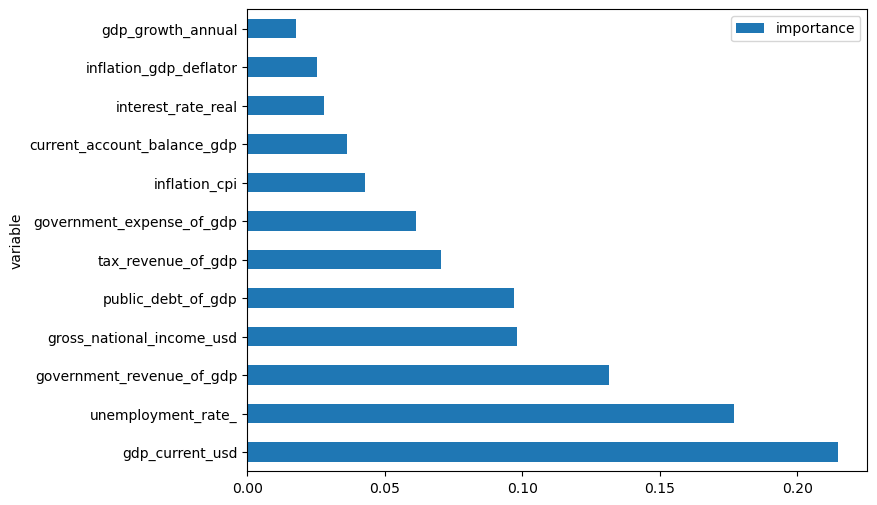

In [ ]:
importances.plot(kind="barh", x="variable", y="importance", figsize=(8,6))

### Facteurs macro-économiques influençant le bonheur

Le modèle Random Forest met en évidence cinq variables macro-économiques majeures associées au niveau de bonheur :

1. **gdp_current_usd** — Le niveau absolu de richesse économique est le facteur le plus déterminant.
2. **unemployment_rate_** — Le chômage a un impact direct et important sur le bien-être.
3. **government_revenue_of_gdp** — Des recettes publiques élevées soutiennent la capacité de financement des services essentiels.
4. **gross_national_income_usd** — Le revenu national brut contribue significativement au niveau de vie global.
5. **public_debt_of_gdp** — La dette publique joue un rôle notable, reflétant la stabilité macro-économique perçue.

Ces cinq variables concentrent l’essentiel de l’influence macro-économique sur le bonheur dans notre modèle.

### Analyse croisée : facteurs WHR vs indicateurs macro-économiques (World Bank)

L’analyse croisée entre les facteurs du World Happiness Report (WHR) et les indicateurs macro-économiques de la Banque Mondiale montre que les deux approches capturent des dimensions différentes du bien-être.

#### 1. Les facteurs WHR dominants
Les variables du WHR les plus explicatives sont généralement :
- **PIB par habitant** (niveau de richesse individuelle)
- **Soutien social**
- **Espérance de vie en bonne santé**
- **Liberté de choix**
- **Générosité**
- **Perception de la corruption**

Ces facteurs décrivent directement la **qualité de vie**, les **relations sociales**, et la **confiance institutionnelle**.

#### 2. Les facteurs macro-économiques dominants (World Bank)
Selon notre modèle, les cinq variables macro-économiques les plus associées au bonheur sont :
1. **gdp_current_usd** — taille globale de l’économie  
2. **unemployment_rate_** — sécurité économique et stabilité du marché du travail  
3. **government_revenue_of_gdp** — capacité de financement public  
4. **gross_national_income_usd** — niveau global de richesse disponible  
5. **public_debt_of_gdp** — stabilité macro-économique perçue  

Ces variables décrivent la **structure économique**, la **capacité de l’État**, et la **stabilité financière**.

#### 3. Ce que révèle la comparaison
- Les facteurs WHR capturent des dimensions **humaines et sociales** du bien-être.  
- Les variables World Bank capturent des dimensions **macro-économiques et structurelles**.  
- Les deux approches sont **complémentaires** :  
  - Le WHR explique *comment les gens vivent* (santé, soutien, liberté).  
  - La Banque Mondiale explique *dans quel environnement économique ils vivent* (richesse, emploi, finances publiques).  

#### 4. Insight clé
Le bonheur n’est pas seulement lié à la richesse individuelle (PIB par habitant), mais aussi à :
- la **taille de l’économie**,  
- la **stabilité du marché du travail**,  
- la **capacité de l’État à financer les services**,  
- la **stabilité macro-économique**.

Les deux modèles convergent sur un point essentiel :  
> **la stabilité économique et institutionnelle est un socle nécessaire, mais pas suffisant, pour un haut niveau de bonheur.**